In [202]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split


#### 1. Setting up configurations

In [203]:
RAW_DATA_PATH = Path('../../data/raw/Telco-Customer-Churn.csv')
PROCESSED_DATA_PATH = Path('../../data/processed')
ARTIFACTS_DIR = Path('../../artifacts')
FIGURE_DIR = Path('../../artifacts/figures')

#### 2. Load data

In [204]:
df = pd.read_csv(f"{PROCESSED_DATA_PATH}/ handled_missing_value.csv")

In [205]:
df.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### 3. Feature Binning 

In [206]:
df_preprocessing = df.copy()


In [207]:
numerical_col = []
categorical_col = []

for col in df_preprocessing.columns:
    if df[col].dtype == 'object':
        categorical_col.append(col)
    else:
        numerical_col.append(col)

print(f"Numerical columns : {numerical_col}")
print(f"Categorical columns : {categorical_col}")

Numerical columns : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns : ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


##### 3.1 Tenure feature
    

<Axes: xlabel='tenure', ylabel='Count'>

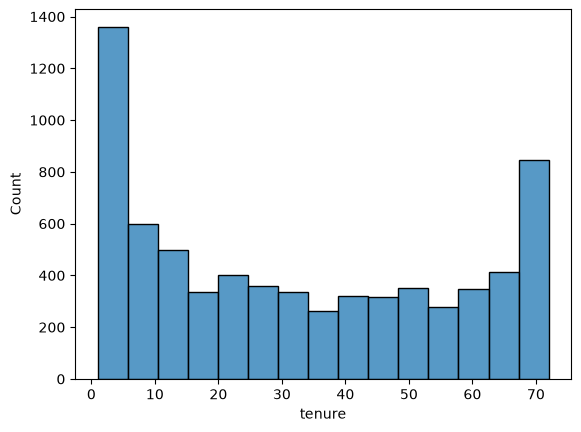

In [208]:
sns.histplot(df_preprocessing['tenure'])

#### Binning stratargy
    - month <= 12 : Freshers
    - month <= 48 : Medium
    - month > 48 : Loyal

In [209]:
def custom_binning_tenure(tenure):
    if tenure <= 12:
        return 'Freshers'
    if tenure <= 48:
        return 'Medium'
    else:
        return 'Loyal'

In [210]:
df_preprocessing['TenureBin'] = df_preprocessing['tenure'].apply(custom_binning_tenure)

<Axes: xlabel='TenureBin', ylabel='count'>

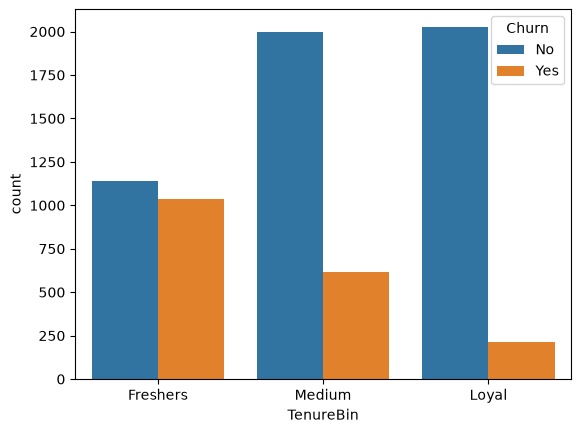

In [211]:
df_preprocessing['TenureBin'].value_counts()
sns.countplot(data = df_preprocessing, x = 'TenureBin', hue = 'Churn')

In [212]:
del df_preprocessing['tenure']

##### 3.2 Churn Feature

#### Churn feature has Yes / No

    -  need to change them into 1 and 0 in same column
    -  Churn(Yes) - 1
    -  Not Churn(No) - 0

In [213]:
def custom_binning_churn(Churn):
    if Churn == 'Yes':
        return 1
    else:
        return 0


In [214]:
df_preprocessing['Churn details'] = df_preprocessing['Churn'].apply(custom_binning_churn)

In [215]:
del df_preprocessing['Churn']

In [216]:
df_preprocessing.head(5)

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,TenureBin,Churn details
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,Freshers,0
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,Medium,0
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Freshers,1
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,Medium,0
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Freshers,1


#### 4. Feature Encoding and scalling

In [217]:
df_preprocessing.head(5)

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,TenureBin,Churn details
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,Freshers,0
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,Medium,0
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Freshers,1
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,Medium,0
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Freshers,1


In [218]:
"""
    Seperate feature names based on the data to encodeing strategy
        - ordinal_features
        - numerical_features
        - reminder_features
        - nominal_features
        - nominal_features_names
"""



ordinal_features = ['Contract','TenureBin']
numerical_features = ['MonthlyCharges','TotalCharges']
reminder_features = ['SeniorCitizen', 'Churn details']

nominal_features = [
                    'gender',
                    'Partner',
                    'Dependents',
                    'PhoneService',
                    'MultipleLines',
                    'InternetService',
                    'OnlineSecurity',
                    'OnlineBackup',
                    'DeviceProtection',
                    'TechSupport',
                    'StreamingTV',
                    'StreamingMovies',
                    'PaperlessBilling',
                    'PaymentMethod'
                ]
                
nominal_features_names = []

In [219]:
numerical_transformer = Pipeline(
                                    steps = [
                                        ('imputer', SimpleImputer(strategy='median')),
                                        ('Scale', StandardScaler())
                                    ]
                                )

nominal_transformer = Pipeline(
                                    steps = [
                                        ('imputer', SimpleImputer(
                                                        strategy='constant',
                                                        fill_value='missing'
                                                    )),   
                                        ('encoder', OneHotEncoder())
                                    ]
                                )

ordinal_transformers = Pipeline(
                                    steps = [
                                        ('imputer', SimpleImputer(
                                                        strategy='constant',
                                                        fill_value='missing'
                                                    )),
                                        ('encoder', OrdinalEncoder())
                                    ]
                                )

preprocessor = ColumnTransformer(
                                    transformers = [
                                                    ('num', numerical_transformer, numerical_features),
                                                    ('nom', nominal_transformer, nominal_features),
                                                    ('ord', ordinal_transformers, ordinal_features)
                                                ],
                                    remainder = 'drop'            
                                )

In [220]:
df_cp = df_preprocessing.copy()

for feature in nominal_features:
    unique_values = df_cp[feature].unique()
    nominal_features_names.extend([f"{feature}_{val}" for val in unique_values])

In [221]:
df_cp['Churn details']

0       0
1       0
2       1
3       0
4       1
       ..
7027    0
7028    0
7029    0
7030    1
7031    0
Name: Churn details, Length: 7032, dtype: int64

In [222]:
df_transformed = pd.DataFrame(
                                preprocessor.fit_transform(df_cp),
                                columns = numerical_features + nominal_features_names + ordinal_features
                            )

df_reminder = df_cp[reminder_features]
df_pp = pd.concat([df_transformed, df_reminder], axis=1)


In [223]:
df_pp.head()

,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_Yes,Partner_No,Dependents_No,Dependents_Yes,PhoneService_No,PhoneService_Yes,...,PaperlessBilling_Yes,PaperlessBilling_No,PaymentMethod_Electronic check,PaymentMethod_Mailed check,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),Contract,TenureBin,SeniorCitizen,Churn details
0,-1.161694,-0.994194,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0
1,-0.260878,-0.173740,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,0,0
2,-0.363923,-0.959649,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0,1
3,-0.747850,-0.195248,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,2.0,0,0
4,0.196178,-0.940457,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0,1


#### 5. Save Data 

In [225]:
df_pp.to_csv(f"{PROCESSED_DATA_PATH}/preprocessed_transformed_data.csv")